# Standard Formula 1 ML models

In [17]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error,
    precision_score, r2_score, recall_score, roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

## 1. Data loading


In [16]:
DATA_DIR = "f1_data"
ZIP_URL = "https://github.com/TracingInsights/RaceData/releases/latest/download/data.zip"


def download_data():
    """Downloads the F1 CSV archive if it is not available yet."""
    os.makedirs(DATA_DIR, exist_ok=True)
    need_file = os.path.join(DATA_DIR, "results.csv")
    if os.path.exists(need_file):
        print("Data is already loaded")
        return

    print("Downloading data archive...")
    zip_path = "f1_data.zip"
    r = requests.get(ZIP_URL, timeout=60)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

    inner = os.path.join(DATA_DIR, "data")
    if os.path.exists(inner):
        for name in os.listdir(inner):
            os.replace(os.path.join(inner, name), os.path.join(DATA_DIR, name))
        os.rmdir(inner)

    print("Done")


download_data()


def read_csv(name):
    return pd.read_csv(os.path.join(DATA_DIR, name))


races = read_csv("races.csv")
results = read_csv("results.csv")
drivers = read_csv("drivers.csv")
constructors = read_csv("constructors.csv")
circuits = read_csv("circuits.csv")
qualifying = read_csv("qualifying.csv")
status = read_csv("status.csv")

Data is already loaded


## 2. Preprocessing


In [20]:
drivers["driver"] = drivers["forename"] + " " + drivers["surname"]
constructors = constructors.rename(columns={"name": "constructor"})
circuits = circuits.rename(columns={"name": "circuit"})
races = races.rename(columns={"year": "season"})

qual_cols = qualifying[["raceId", "driverId", "position"]].rename(
    columns={"position": "qual_position"}
)

df = (
    results
    .merge(races[["raceId", "season", "round", "circuitId", "date"]], on="raceId")
    .merge(drivers[["driverId", "driver"]], on="driverId")
    .merge(constructors[["constructorId", "constructor"]], on="constructorId")
    .merge(circuits[["circuitId", "circuit", "country"]], on="circuitId")
    .merge(status[["statusId", "status"]], on="statusId", how="left")
    .merge(qual_cols, on=["raceId", "driverId"], how="left")
)

df = df.sort_values(["season", "round", "raceId", "driverId"]).reset_index(drop=True)

df["target_position"] = pd.to_numeric(df["positionOrder"], errors="coerce")
df["grid"] = pd.to_numeric(df["grid"], errors="coerce").replace(0, np.nan)
df["qual_position"] = pd.to_numeric(df["qual_position"], errors="coerce")
df["points"] = pd.to_numeric(df["points"], errors="coerce").fillna(0)

# The Ergast-style data does not include regular race weather, so this value is set to unknown.
df["weather"] = "unknown"

finished_mask = df["status"].fillna("").str.contains("Finished", case=False)
lap_mask = df["status"].fillna("").str.startswith("+")
df["dnf"] = (~(finished_mask | lap_mask)).astype(int)
df["is_podium"] = (df["target_position"] <= 3).astype(int)

## 3. Feature engineering


In [22]:
def add_driver_features(data):
    data = data.copy()
    g = data.groupby("driverId", group_keys=False)

    data["avg_position_last_3"] = g["target_position"].apply(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    data["avg_position_season"] = data.groupby(["season", "driverId"], group_keys=False)[
        "target_position"
    ].apply(lambda x: x.shift(1).expanding().mean())
    data["podium_pct_season"] = data.groupby(["season", "driverId"], group_keys=False)[
        "is_podium"
    ].apply(lambda x: x.shift(1).expanding().mean())
    data["points_last_5"] = g["points"].apply(
        lambda x: x.shift(1).rolling(5, min_periods=1).sum()
    )
    data["dnf_pct_last_5"] = g["dnf"].apply(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
    data["constructor_avg_last_3"] = data.groupby("constructorId", group_keys=False)[
        "target_position"
    ].apply(lambda x: x.shift(1).rolling(3, min_periods=1).mean())

    return data


df = add_driver_features(df)

num_features = [
    "grid", "qual_position", "avg_position_last_3", "avg_position_season",
    "podium_pct_season", "points_last_5", "dnf_pct_last_5",
    "constructor_avg_last_3"
]
cat_features = ["driver", "constructor", "circuit", "country", "weather"]

for col in num_features:
    df[col] = df[col].fillna(df[col].median())

df = df[(df["season"] >= 2013) & (df["season"] <= 2023)].copy()

train = df[df["season"] <= 2022].copy()
test = df[df["season"] == 2023].copy()

X_train = train[num_features + cat_features]
X_test = test[num_features + cat_features]
y_train_pos = train["target_position"]
y_test_pos = test["target_position"]
y_train_podium = train["is_podium"]
y_test_podium = test["is_podium"]

print("Train:", train.shape)
print("Test 2023:", test.shape)

Train: (4125, 38)
Test 2023: (440, 38)


## 4. Models


In [24]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    sparse_threshold=0
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=120, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        random_state=42,
        objective="reg:squarederror"
    )
else:
    print("XGBoost is not installed. In Colab, run: !pip install xgboost")

trained_models = {}
regression_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train_pos)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test_pos, pred)
    rmse = np.sqrt(mean_squared_error(y_test_pos, pred))
    r2 = r2_score(y_test_pos, pred)

    trained_models[name] = pipe
    regression_results.append([name, mae, rmse, r2])

regression_table = pd.DataFrame(
    regression_results,
    columns=["model", "MAE", "RMSE", "R2"]
).sort_values("MAE")

print(regression_table)

best_model_name = regression_table.iloc[0]["model"]
best_model = trained_models[best_model_name]
print("Best position model:", best_model_name)


# Logistic regression for podium probability
podium_model = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])
podium_model.fit(X_train, y_train_podium)
podium_prob = podium_model.predict_proba(X_test)[:, 1]

# For each race, the top 3 probabilities are used instead of one global threshold.
test["podium_probability"] = podium_prob
test["predicted_podium"] = 0
for race_id, part in test.groupby("raceId"):
    idx = part.sort_values("podium_probability", ascending=False).head(3).index
    test.loc[idx, "predicted_podium"] = 1

classification_metrics = pd.DataFrame([{
    "ROC_AUC": roc_auc_score(y_test_podium, podium_prob),
    "Accuracy": accuracy_score(y_test_podium, test["predicted_podium"]),
    "Precision": precision_score(y_test_podium, test["predicted_podium"]),
    "Recall": recall_score(y_test_podium, test["predicted_podium"]),
    "F1": f1_score(y_test_podium, test["predicted_podium"]),
}])

print(classification_metrics)

               model       MAE      RMSE        R2
2  Gradient Boosting  3.283870  4.295332  0.445117
3            XGBoost  3.291141  4.292062  0.445961
0  Linear Regression  3.386394  4.359641  0.428377
1      Random Forest  3.423125  4.465527  0.400273
Best position model: Gradient Boosting
    ROC_AUC  Accuracy  Precision    Recall        F1
0  0.921609  0.890909   0.636364  0.636364  0.636364


## 5. 2023 season predictions


In [26]:
test["predicted_position_raw"] = best_model.predict(X_test)
test["predicted_position"] = (
    test.groupby("raceId")["predicted_position_raw"]
    .rank(method="first")
    .astype(int)
)

prediction_table = test[[
    "season", "round", "driver", "constructor", "circuit",
    "grid", "qual_position", "target_position",
    "predicted_position", "podium_probability"
]].sort_values(["round", "predicted_position"])

prediction_table.head(30)

,season,round,driver,constructor,circuit,grid,qual_position,target_position,predicted_position,podium_probability
25846,2023,1,Max Verstappen,Red Bull,Bahrain International Circuit,1.0,1.0,1,1,0.822289
25851,2023,1,Charles Leclerc,Ferrari,Bahrain International Circuit,3.0,3.0,19,2,0.440565
25843,2023,1,Sergio Pérez,Red Bull,Bahrain International Circuit,2.0,2.0,2,3,0.619379
25853,2023,1,George Russell,Mercedes,Bahrain International Circuit,6.0,6.0,7,4,0.342072
25840,2023,1,Lewis Hamilton,Mercedes,Bahrain International Circuit,7.0,7.0,5,5,0.336713
25847,2023,1,Carlos Sainz,Ferrari,Bahrain International Circuit,4.0,4.0,4,6,0.391906
25841,2023,1,Fernando Alonso,Aston Martin,Bahrain International Circuit,5.0,5.0,3,7,0.092681
25849,2023,1,Lance Stroll,Aston Martin,Bahrain International Circuit,8.0,8.0,6,8,0.040340
25848,2023,1,Esteban Ocon,Alpine F1 Team,Bahrain International Circuit,9.0,9.0,18,9,0.021546
25852,2023,1,Lando Norris,McLaren,Bahrain International Circuit,11.0,11.0,17,10,0.018963


## 6. Season result comparison


In [28]:
F1_POINTS = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}

test["real_points_calc"] = test["target_position"].map(F1_POINTS).fillna(0)
test["pred_points_calc"] = test["predicted_position"].map(F1_POINTS).fillna(0)

season_compare = (
    test.groupby("driver")[["real_points_calc", "pred_points_calc"]]
    .sum()
    .reset_index()
)
season_compare["abs_error"] = (
    season_compare["real_points_calc"] - season_compare["pred_points_calc"]
).abs()
season_compare = season_compare.sort_values("real_points_calc", ascending=False)

season_compare

real_podiums = int(test["is_podium"].sum())
pred_podiums = int(test["predicted_podium"].sum())
print("Real podiums in 2023:", real_podiums)
print("Predicted podiums in 2023:", pred_podiums)
print("Error:", abs(real_podiums - pred_podiums))

Real podiums in 2023: 66
Predicted podiums in 2023: 66
Error: 0


## 7. Charts


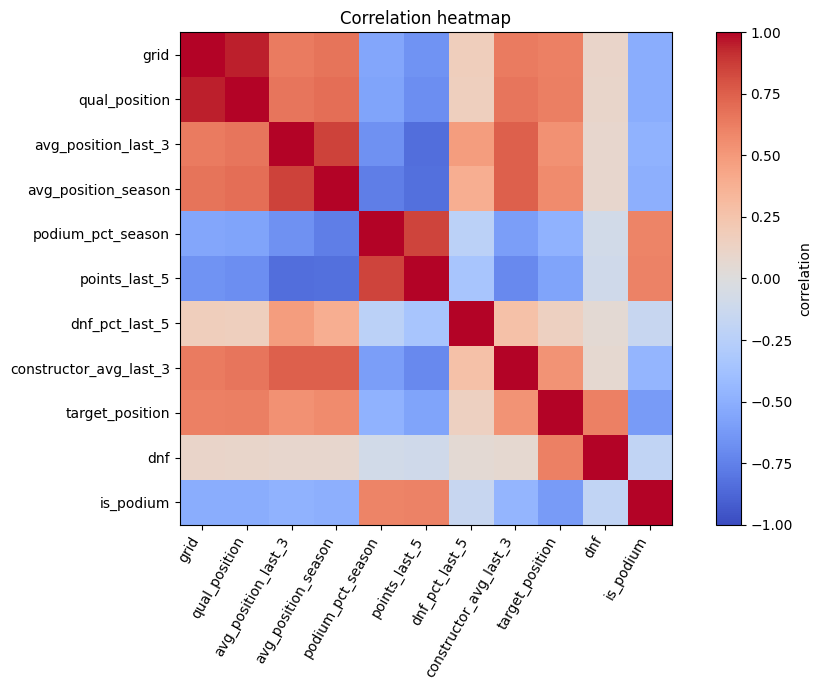

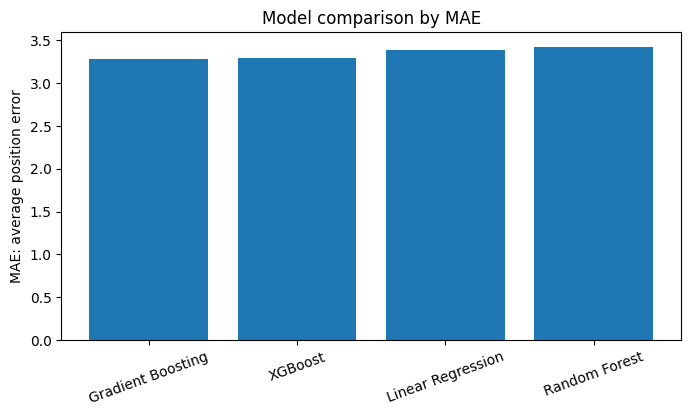

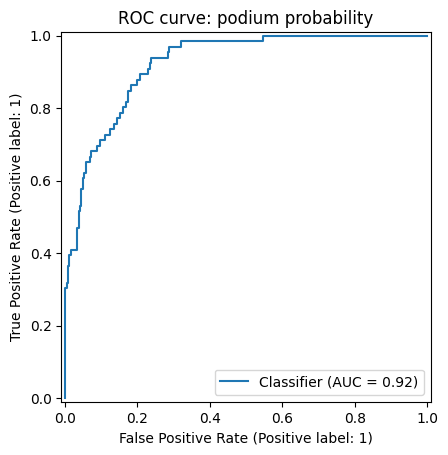

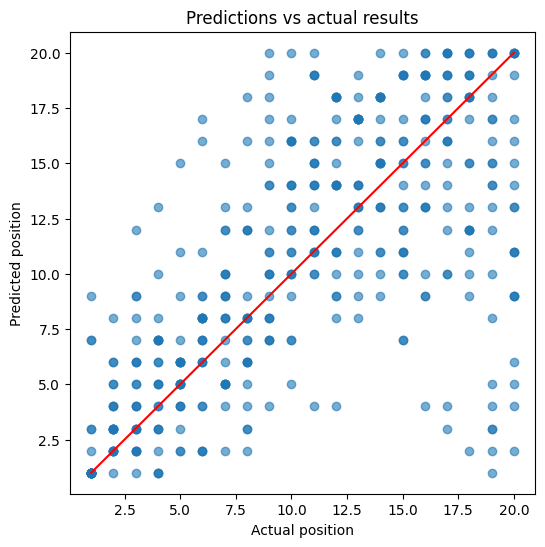

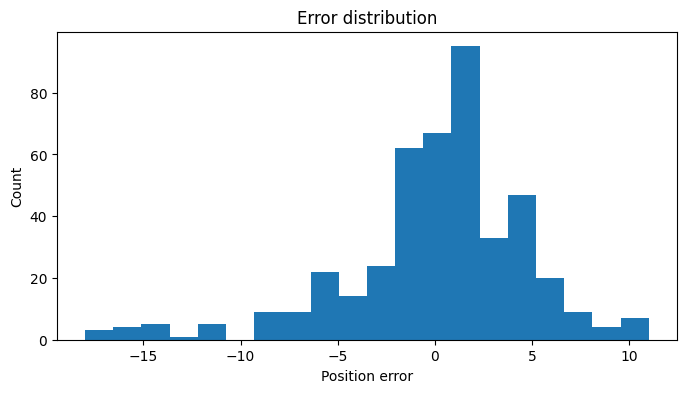

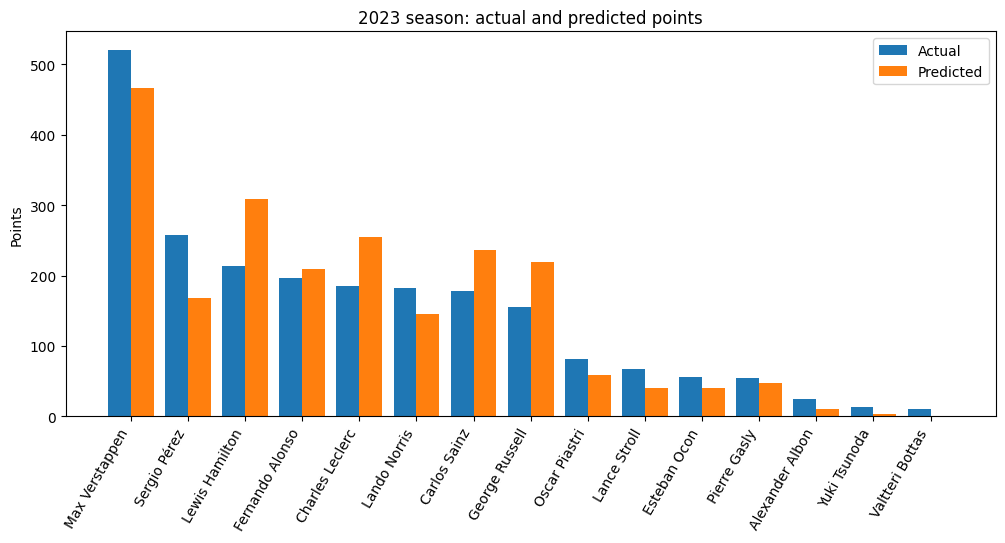

Random Forest feature importance table:


,feature,importance
1,qual_position,0.304759
0,grid,0.119824
3,avg_position_season,0.098258
5,points_last_5,0.072142
7,constructor_avg_last_3,0.067757
2,avg_position_last_3,0.050269
4,podium_pct_season,0.034238
6,dnf_pct_last_5,0.016442
14,driver_Carlos Sainz,0.004027
23,driver_Fernando Alonso,0.004020


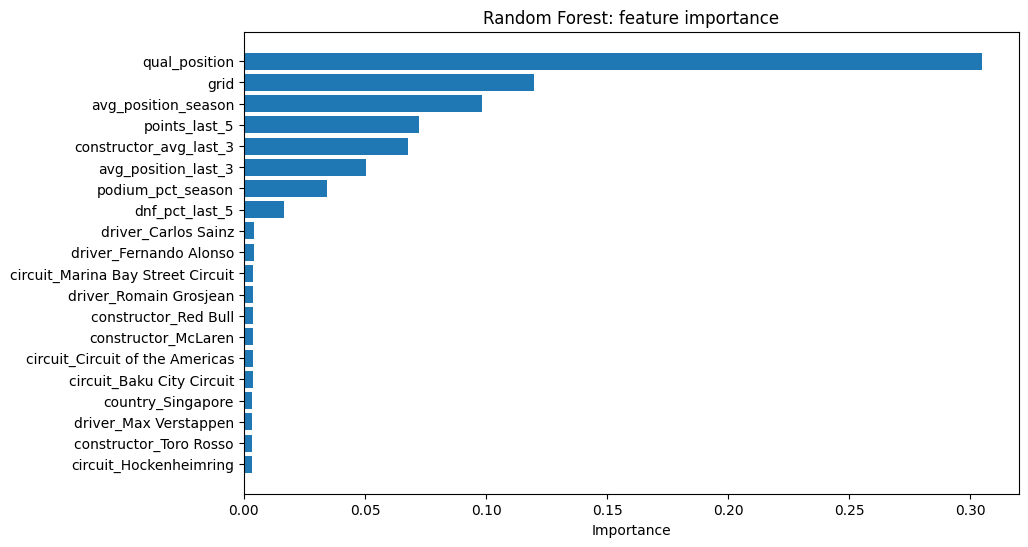

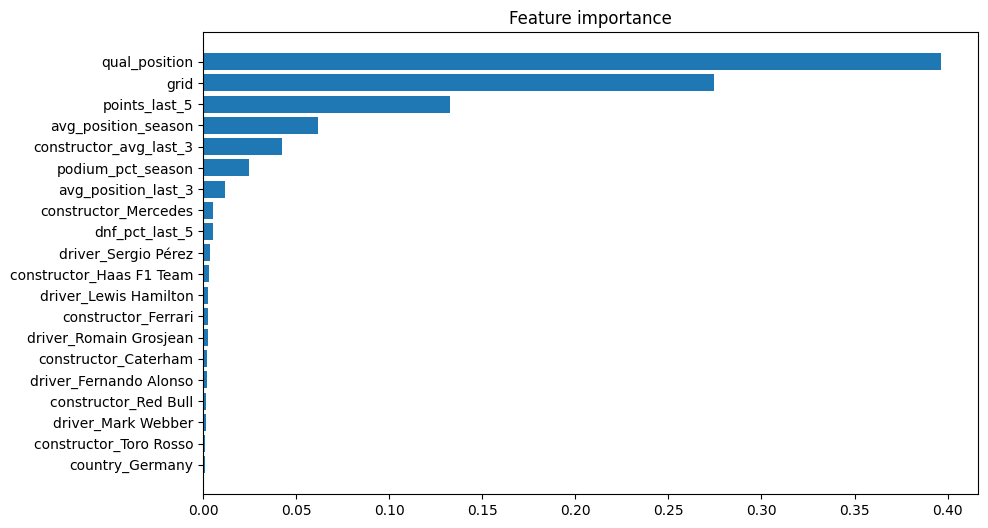


Round 1


,driver,constructor,target_position,predicted_position,podium_probability
25846,Max Verstappen,Red Bull,1,1,0.822289
25851,Charles Leclerc,Ferrari,19,2,0.440565
25843,Sergio Pérez,Red Bull,2,3,0.619379
25853,George Russell,Mercedes,7,4,0.342072
25840,Lewis Hamilton,Mercedes,5,5,0.336713
25847,Carlos Sainz,Ferrari,4,6,0.391906
25841,Fernando Alonso,Aston Martin,3,7,0.092681
25849,Lance Stroll,Aston Martin,6,8,0.040340
25848,Esteban Ocon,Alpine F1 Team,18,9,0.021546
25852,Lando Norris,McLaren,17,10,0.018963



Round 2


,driver,constructor,target_position,predicted_position,podium_probability
25873,George Russell,Mercedes,4,1,0.518807
25867,Carlos Sainz,Ferrari,6,2,0.312497
25861,Fernando Alonso,Aston Martin,3,3,0.347506
25860,Lewis Hamilton,Mercedes,5,4,0.290022
25871,Charles Leclerc,Ferrari,7,5,0.151683
25869,Lance Stroll,Aston Martin,20,6,0.095206
25868,Esteban Ocon,Alpine F1 Team,8,7,0.043535
25866,Max Verstappen,Red Bull,2,8,0.123214
25863,Sergio Pérez,Red Bull,1,9,0.793697
25870,Pierre Gasly,Alpine F1 Team,9,10,0.011663



Round 3


,driver,constructor,target_position,predicted_position,podium_probability
25886,Max Verstappen,Red Bull,1,1,0.892340
25893,George Russell,Mercedes,18,2,0.644165
25880,Lewis Hamilton,Mercedes,2,3,0.590936
25887,Carlos Sainz,Ferrari,12,4,0.278456
25891,Charles Leclerc,Ferrari,20,5,0.154562
25881,Fernando Alonso,Aston Martin,3,6,0.282997
25889,Lance Stroll,Aston Martin,4,7,0.082091
25890,Pierre Gasly,Alpine F1 Team,13,8,0.016567
25888,Esteban Ocon,Alpine F1 Team,14,9,0.013900
25894,Alexander Albon,Williams,19,10,0.031176


In [30]:
corr_cols = num_features + ["target_position", "dnf", "is_podium"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(regression_table["model"], regression_table["MAE"])
plt.title("Model comparison by MAE")
plt.ylabel("MAE: average position error")
plt.xticks(rotation=20)
plt.show()

RocCurveDisplay.from_predictions(y_test_podium, podium_prob)
plt.title("ROC curve: podium probability")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(test["target_position"], test["predicted_position"], alpha=0.6)
plt.plot([1, 20], [1, 20], color="red")
plt.xlabel("Actual position")
plt.ylabel("Predicted position")
plt.title("Predictions vs actual results")
plt.show()

test["position_error"] = test["predicted_position"] - test["target_position"]
plt.figure(figsize=(8, 4))
plt.hist(test["position_error"], bins=20)
plt.title("Error distribution")
plt.xlabel("Position error")
plt.ylabel("Count")
plt.show()

top_season = season_compare.head(15)
plt.figure(figsize=(12, 5))
x = np.arange(len(top_season))
plt.bar(x - 0.2, top_season["real_points_calc"], width=0.4, label="Actual")
plt.bar(x + 0.2, top_season["pred_points_calc"], width=0.4, label="Predicted")
plt.xticks(x, top_season["driver"], rotation=60, ha="right")
plt.title("2023 season: actual and predicted points")
plt.ylabel("Points")
plt.legend()
plt.show()


# Feature importance for the best model, if it supports it
def get_feature_names(pipe):
    prep = pipe.named_steps["prep"]
    cat_names = prep.named_transformers_["cat"].get_feature_names_out(cat_features)
    return np.r_[num_features, cat_names]


rf_model = trained_models["Random Forest"]
rf_names = get_feature_names(rf_model)
rf_importances = rf_model.named_steps["model"].feature_importances_
rf_importance_table = pd.DataFrame({
    "feature": rf_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

print("Random Forest feature importance table:")
display(rf_importance_table.head(20))

plt.figure(figsize=(10, 6))
plt.barh(
    rf_importance_table.head(20)["feature"],
    rf_importance_table.head(20)["importance"]
)
plt.gca().invert_yaxis()
plt.title("Random Forest: feature importance")
plt.xlabel("Importance")
plt.show()


if hasattr(best_model.named_steps["model"], "feature_importances_"):
    names = get_feature_names(best_model)
    importances = best_model.named_steps["model"].feature_importances_
    imp = pd.DataFrame({"feature": names, "importance": importances})
    imp = imp.sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(imp["feature"], imp["importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature importance")
    plt.show()
else:
    print("The best model does not have feature_importances_. Use Random Forest or Gradient Boosting for this chart.")


# Race-level output: actual position vs prediction
for rnd in sorted(test["round"].unique())[:3]:
    print("\nRound", rnd)
    display(prediction_table[prediction_table["round"] == rnd][[
        "driver", "constructor", "target_position", "predicted_position", "podium_probability"
    ]])